# CISE301 — Topic 4: Least Squares Curve Fitting
**Solver: Gauss-Jordan Elimination**

Setiap metode diterapkan pada dua dataset:
- **Dataset A** — data Contoh 3 (Polynomial Regression)
- **Dataset B** — data Contoh 4 (Nonlinear Least Squares)

In [1]:
import copy
import numpy as np
import matplotlib.pyplot as plt

# ── Gauss-Jordan Elimination ────────────────────────────────────────────────

def cetak_matriks(A, B, judul=""):
    n = len(A)
    if judul:
        print(f"  [{judul}]")
    print("  " + "-" * 44)
    for i in range(n):
        baris = "  | "
        for j in range(n):
            baris += f"{A[i][j]:8.4f} "
        baris += f"| {B[i]:8.4f} |"
        print(baris)
    print("  " + "-" * 44)


def gauss_jordan(A_input, B_input, verbose=True):
    """
    Gauss-Jordan Elimination: Ax = B  →  x
    Hasil akhir: A menjadi Identity Matrix, B = solusi X.
    """
    n = len(A_input)
    A = copy.deepcopy(A_input)
    B = copy.deepcopy(B_input)

    if verbose:
        print("=" * 50)
        print("  GAUSS-JORDAN ELIMINATION")
        print("=" * 50)
        cetak_matriks(A, B, "Matriks Awal [A|B]")

    for k in range(n):
        if A[k][k] == 0:
            swapped = False
            for r in range(k + 1, n):
                if A[r][k] != 0:
                    A[k], A[r] = A[r], A[k]
                    B[k], B[r] = B[r], B[k]
                    if verbose:
                        print(f"  ! Pivot=0, tukar R{k+1} <-> R{r+1}")
                    swapped = True
                    break
            if not swapped:
                print(f"  ! Sistem singular pada kolom {k+1}!")
                return None

        pivot = A[k][k]
        if verbose:
            print(f"\n  Langkah {k+1}: normalisasi R{k+1} (bagi {pivot:.4f})")

        for j in range(n):
            A[k][j] /= pivot
        B[k] /= pivot

        for i in range(n):
            if i == k or A[i][k] == 0:
                continue
            faktor = A[i][k]
            if verbose:
                print(f"  R{i+1} = R{i+1} - ({faktor:.4f}) x R{k+1}")
            for j in range(n):
                A[i][j] -= faktor * A[k][j]
            B[i] -= faktor * B[k]

        if verbose:
            cetak_matriks(A, B, f"Setelah Langkah {k+1}")

    return list(B)


def hitung_r2(y_actual, y_pred):
    y_actual = np.array(y_actual, dtype=float)
    y_pred   = np.array(y_pred,   dtype=float)
    ss_res = np.sum((y_actual - y_pred) ** 2)
    ss_tot = np.sum((y_actual - np.mean(y_actual)) ** 2)
    return 1 - ss_res / ss_tot if ss_tot != 0 else 1.0

print("✓ Import & fungsi Gauss-Jordan siap.")

✓ Import & fungsi Gauss-Jordan siap.


---
## Dataset A — Data Contoh 3
`x = [0, 1, 2, 3, 4, 5]`  
`y = [2.1, 7.7, 13.6, 27.2, 40.9, 61.1]`

Dataset A:
  x = [0.0, 1.0, 2.0, 3.0, 4.0, 5.0]
  y = [2.1, 7.7, 13.6, 27.2, 40.9, 61.1]
  n = 6


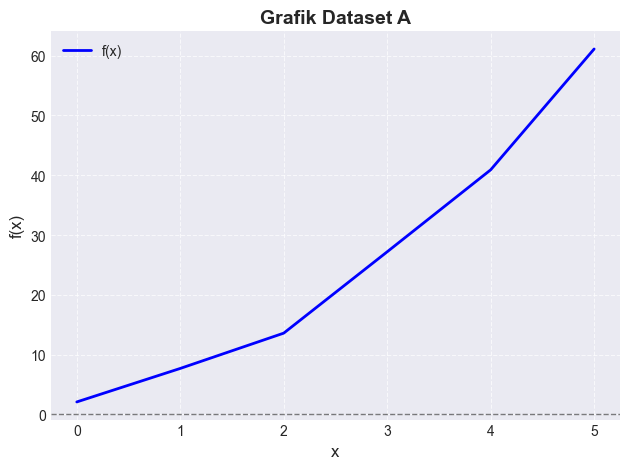

In [2]:
# Dataset A — Contoh 3
xA = np.array([0, 1, 2, 3, 4, 5], dtype=float)
yA = np.array([2.1, 7.7, 13.6, 27.2, 40.9, 61.1], dtype=float)
nA = len(xA)

print("Dataset A:")
print(f"  x = {xA.tolist()}")
print(f"  y = {yA.tolist()}")
print(f"  n = {nA}")

plt.style.use('seaborn-v0_8-darkgrid')
# Plot Fungsi
plt.plot(xA, yA, label='f(x)', color='blue', linewidth=2)

# Plot Garis Y = 0
plt.axhline(0, color='black', linewidth=1, linestyle='--', alpha=0.5)
plt.title(f'Grafik Dataset A', fontsize=14, fontweight='bold')
plt.xlabel('x', fontsize=12)
plt.ylabel('f(x)', fontsize=12)
plt.legend(loc='best')
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

Dataset B:
  x = [0.24, 0.65, 0.95, 1.24, 1.73, 2.01, 2.23, 2.52]
  y = [0.23, -0.23, -1.1, -0.45, 0.27, 0.1, -0.29, 0.24]
  n = 8


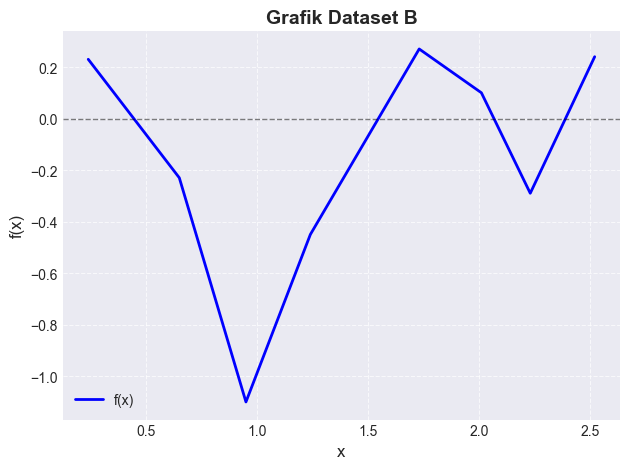

In [3]:
# Dataset B — Contoh 4
xB = np.array([0.24, 0.65, 0.95, 1.24, 1.73, 2.01, 2.23, 2.52], dtype=float)
yB = np.array([0.23, -0.23, -1.1, -0.45, 0.27, 0.1, -0.29, 0.24], dtype=float)
nB = len(xB)

print("Dataset B:")
print(f"  x = {xB.tolist()}")
print(f"  y = {yB.tolist()}")
print(f"  n = {nB}")

plt.style.use('seaborn-v0_8-darkgrid')

# Plot Fungsi
plt.plot(xB, yB, label='f(x)', color='blue', linewidth=2)

# Plot Garis Y = 0
plt.axhline(0, color='black', linewidth=1, linestyle='--', alpha=0.5)
plt.title(f'Grafik Dataset B', fontsize=14, fontweight='bold')
plt.xlabel('x', fontsize=12)
plt.ylabel('f(x)', fontsize=12)
plt.legend(loc='best')
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

---
## Metode 1: Linear Regression
### Dataset A

Linear Regression | Dataset A
Model: y = a0 + a1*x

Sums: n=6, Σx=15.0, Σy=152.6, Σx²=55.0, Σxy=585.6

Normal Equations:
  [ 6,     15.0000  ] [a0]   [ 152.6000  ]
  [ 15.0000, 55.0000  ] [a1] = [ 585.6000 ]

  GAUSS-JORDAN ELIMINATION
  [Matriks Awal [A|B]]
  --------------------------------------------
  |   6.0000  15.0000 | 152.6000 |
  |  15.0000  55.0000 | 585.6000 |
  --------------------------------------------

  Langkah 1: normalisasi R1 (bagi 6.0000)
  R2 = R2 - (15.0000) x R1
  [Setelah Langkah 1]
  --------------------------------------------
  |   1.0000   2.5000 |  25.4333 |
  |   0.0000  17.5000 | 204.1000 |
  --------------------------------------------

  Langkah 2: normalisasi R2 (bagi 17.5000)
  R1 = R1 - (2.5000) x R2
  [Setelah Langkah 2]
  --------------------------------------------
  |   1.0000   0.0000 |  -3.7238 |
  |   0.0000   1.0000 |  11.6629 |
  --------------------------------------------

── HASIL ────────────────────────────
a0 = -3.723810
a1 = 11.662

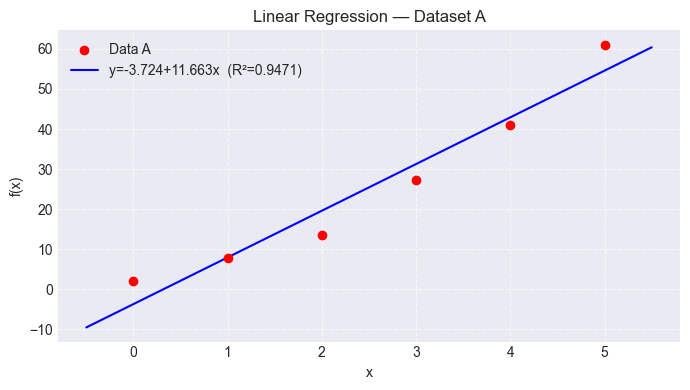

In [4]:
# ── Linear Regression — Dataset A ──────────────────────────────────────────
# Model: y = a0 + a1*x
print("Linear Regression | Dataset A")
print("Model: y = a0 + a1*x\n")

x, y, n = xA, yA, nA
sum_x  = np.sum(x);  sum_y  = np.sum(y)
sum_x2 = np.sum(x**2); sum_xy = np.sum(x*y)

print(f"Sums: n={n}, Σx={sum_x}, Σy={sum_y}, Σx²={sum_x2}, Σxy={sum_xy}")
print("\nNormal Equations:")
print(f"  [ {n:.0f},     {sum_x:.4f}  ] [a0]   [ {sum_y:.4f}  ]")
print(f"  [ {sum_x:.4f}, {sum_x2:.4f}  ] [a1] = [ {sum_xy:.4f} ]\n")

A_mat = [[float(n),   sum_x],
         [sum_x, sum_x2]]
B_vec = [sum_y, sum_xy]
sol = gauss_jordan(A_mat, B_vec)
a0, a1 = sol

y_pred = a0 + a1*x
r2 = hitung_r2(y, y_pred)
print(f"\n── HASIL ────────────────────────────")
print(f"a0 = {a0:.6f}")
print(f"a1 = {a1:.6f}")
print(f"Model: y = {a0:.4f} + {a1:.4f}·x")
print(f"R²   = {r2:.6f}")
print("\nVerifikasi:")
for xi, yi, yp in zip(x, y, y_pred):
    print(f"  x={xi}: y_pred={yp:.4f}  | y_actual={yi}")

x_plot = np.linspace(-0.5, 5.5, 300)
y_plot = a0 + a1*x_plot
plt.figure(figsize=(7,4))
plt.scatter(x, y, color='red', zorder=5, label='Data A')
plt.plot(x_plot, y_plot, 'b-', label=f'y={a0:.3f}+{a1:.3f}x  (R²={r2:.4f})')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Linear Regression — Dataset A')
plt.legend(loc='best')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Dataset B

Linear Regression | Dataset B
Model: y = a0 + a1*x

Sums: n=8, Σx=11.5700, Σy=-1.2300, Σx²=21.2765, Σxy=-1.0711

Normal Equations:
  [ 8,       11.5700  ] [a0]   [ -1.2300  ]
  [ 11.5700,  21.2765  ] [a1] = [ -1.0711 ]

  GAUSS-JORDAN ELIMINATION
  [Matriks Awal [A|B]]
  --------------------------------------------
  |   8.0000  11.5700 |  -1.2300 |
  |  11.5700  21.2765 |  -1.0711 |
  --------------------------------------------

  Langkah 1: normalisasi R1 (bagi 8.0000)
  R2 = R2 - (11.5700) x R1
  [Setelah Langkah 1]
  --------------------------------------------
  |   1.0000   1.4463 |  -0.1537 |
  |   0.0000   4.5434 |   0.7078 |
  --------------------------------------------

  Langkah 2: normalisasi R2 (bagi 4.5434)
  R1 = R1 - (1.4463) x R2
  [Setelah Langkah 2]
  --------------------------------------------
  |   1.0000   0.0000 |  -0.3791 |
  |   0.0000   1.0000 |   0.1558 |
  --------------------------------------------

── HASIL ────────────────────────────
a0 = -0.379053
a

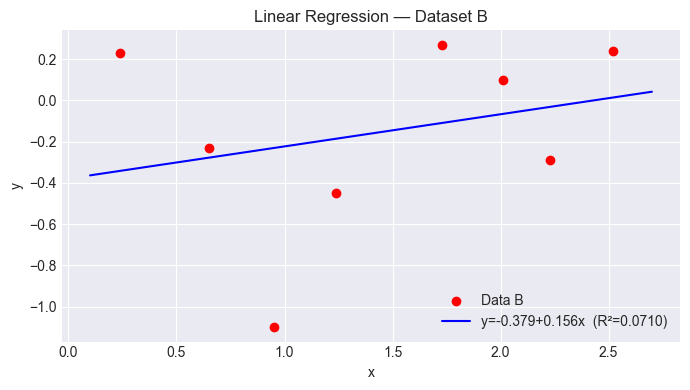

In [5]:
# ── Linear Regression — Dataset B ──────────────────────────────────────────
print("Linear Regression | Dataset B")
print("Model: y = a0 + a1*x\n")

x, y, n = xB, yB, nB
sum_x  = np.sum(x);  sum_y  = np.sum(y)
sum_x2 = np.sum(x**2); sum_xy = np.sum(x*y)

print(f"Sums: n={n}, Σx={sum_x:.4f}, Σy={sum_y:.4f}, Σx²={sum_x2:.4f}, Σxy={sum_xy:.4f}")
print("\nNormal Equations:")
print(f"  [ {n:.0f},       {sum_x:.4f}  ] [a0]   [ {sum_y:.4f}  ]")
print(f"  [ {sum_x:.4f},  {sum_x2:.4f}  ] [a1] = [ {sum_xy:.4f} ]\n")

A_mat = [[float(n),   sum_x],
         [sum_x, sum_x2]]
B_vec = [sum_y, sum_xy]
sol = gauss_jordan(A_mat, B_vec)
a0, a1 = sol

y_pred = a0 + a1*x
r2 = hitung_r2(y, y_pred)
print(f"\n── HASIL ────────────────────────────")
print(f"a0 = {a0:.6f}")
print(f"a1 = {a1:.6f}")
print(f"Model: y = {a0:.4f} + {a1:.4f}·x")
print(f"R²   = {r2:.6f}")
print("\nVerifikasi:")
for xi, yi, yp in zip(x, y, y_pred):
    print(f"  x={xi}: y_pred={yp:.4f}  | y_actual={yi}")

x_plot = np.linspace(0.1, 2.7, 300)
y_plot = a0 + a1*x_plot

plt.figure(figsize=(7,4))
plt.scatter(x, y, color='red', zorder=5, label='Data B')
plt.plot(x_plot, y_plot, 'b-', label=f'y={a0:.3f}+{a1:.3f}x  (R²={r2:.4f})')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Linear Regression — Dataset B')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

---
## Metode 2: Multiple Linear Regression
> Variabel kedua `t` = indeks data (0, 1, 2, …) sebagai variabel tambahan.

### Dataset A

Multiple Linear Regression | Dataset A
Model: f(x,t) = a + b·x + c·t  (t = x²)

t = x² = [0.0, 1.0, 4.0, 9.0, 16.0, 25.0]
Sums: Σx=15.0, Σt=55.0, Σy=152.6
      Σx²=55.0, Σxt=225.0, Σxy=585.6, Σt²=979.0, Σty=2488.8

Normal Equations (3×3):
  [ 6,      15.0000,  55.0000  ] [a]   [ 152.6000  ]
  [ 15.0000, 55.0000, 225.0000  ] [b] = [ 585.6000 ]
  [ 55.0000,  225.0000, 979.0000  ] [c]   [ 2488.8000 ]

  GAUSS-JORDAN ELIMINATION
  [Matriks Awal [A|B]]
  --------------------------------------------
  |   6.0000  15.0000  55.0000 | 152.6000 |
  |  15.0000  55.0000 225.0000 | 585.6000 |
  |  55.0000 225.0000 979.0000 | 2488.8000 |
  --------------------------------------------

  Langkah 1: normalisasi R1 (bagi 6.0000)
  R2 = R2 - (15.0000) x R1
  R3 = R3 - (55.0000) x R1
  [Setelah Langkah 1]
  --------------------------------------------
  |   1.0000   2.5000   9.1667 |  25.4333 |
  |   0.0000  17.5000  87.5000 | 204.1000 |
  |   0.0000  87.5000 474.8333 | 1089.9667 |
  -------------------

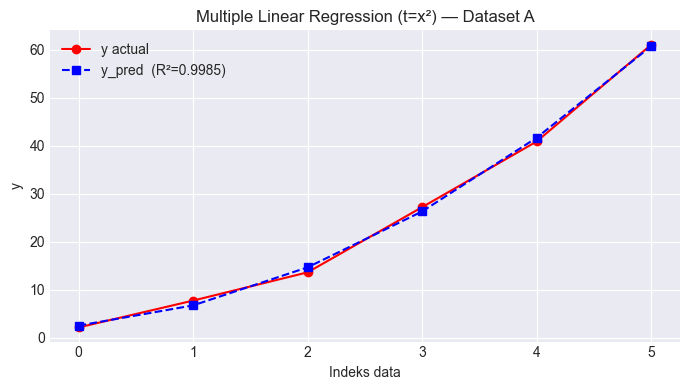

In [6]:
# ── Multiple Linear Regression — Dataset A ─────────────────────────────────
# Model: f(x, t) = a + b*x + c*t,  t = x² (variabel kedua independen)
# Catatan: t=indeks identik dengan x=[0,1,2,3,4,5] → singular
# Maka digunakan t = x² sebagai variabel kedua yang independen
print("Multiple Linear Regression | Dataset A")
print("Model: f(x,t) = a + b·x + c·t  (t = x²)\n")

x, y, n = xA, yA, nA
t = x**2   # variabel kedua: t = x²

sum_x  = np.sum(x);  sum_t  = np.sum(t);  sum_y  = np.sum(y)
sum_x2 = np.sum(x**2); sum_xt = np.sum(x*t); sum_t2 = np.sum(t**2)
sum_xy = np.sum(x*y);  sum_ty = np.sum(t*y)

print(f"t = x² = {t.tolist()}")
print(f"Sums: Σx={sum_x}, Σt={sum_t}, Σy={sum_y}")
print(f"      Σx²={sum_x2}, Σxt={sum_xt}, Σxy={sum_xy}, Σt²={sum_t2}, Σty={sum_ty}")
print("\nNormal Equations (3×3):")
print(f"  [ {n:.0f},      {sum_x:.4f},  {sum_t:.4f}  ] [a]   [ {sum_y:.4f}  ]")
print(f"  [ {sum_x:.4f}, {sum_x2:.4f}, {sum_xt:.4f}  ] [b] = [ {sum_xy:.4f} ]")
print(f"  [ {sum_t:.4f},  {sum_xt:.4f}, {sum_t2:.4f}  ] [c]   [ {sum_ty:.4f} ]\n")

A_mat = [[float(n), sum_x,  sum_t],
         [sum_x,    sum_x2, sum_xt],
         [sum_t,    sum_xt, sum_t2]]
B_vec = [sum_y, sum_xy, sum_ty]
sol = gauss_jordan(A_mat, B_vec)
a, b, c = sol

y_pred = a + b*x + c*t
r2 = hitung_r2(y, y_pred)
print(f"\n── HASIL ────────────────────────────")
print(f"a = {a:.6f}")
print(f"b = {b:.6f}")
print(f"c = {c:.6f}")
print(f"Model: f(x,x²) = {a:.4f} + ({b:.4f})·x + ({c:.4f})·x²")
print(f"R²   = {r2:.6f}")
print("\nVerifikasi:")
for xi, ti, yi, yp in zip(x, t, y, y_pred):
    print(f"  x={xi}, t=x²={ti:.0f}: f_pred={yp:.4f}  | y_actual={yi}")

plt.figure(figsize=(7,4))
plt.plot(range(n), y, 'ro-', label='y actual')
plt.plot(range(n), y_pred, 'bs--', label=f'y_pred  (R²={r2:.4f})')
plt.xlabel('Indeks data'); plt.ylabel('y')
plt.title('Multiple Linear Regression (t=x²) — Dataset A')
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

### Dataset B

Multiple Linear Regression | Dataset B
Model: f(x,t) = a + b·x + c·t  (t = x²)

t = x² = [0.0576, 0.4225, 0.9025, 1.5376, 2.9929, 4.0401, 4.9729, 6.3504]
Sums: Σx=11.5700, Σt=21.2765, Σy=-1.2300
      Σx²=21.2765, Σxt=43.4433, Σxy=-1.0711, Σt²=93.6977, Σty=-0.4745

Normal Equations (3×3):
  [ 8,      11.5700,  21.2765  ] [a]   [ -1.2300  ]
  [ 11.5700, 21.2765, 43.4433  ] [b] = [ -1.0711 ]
  [ 21.2765,  43.4433, 93.6977  ] [c]   [ -0.4745 ]

  GAUSS-JORDAN ELIMINATION
  [Matriks Awal [A|B]]
  --------------------------------------------
  |   8.0000  11.5700  21.2765 |  -1.2300 |
  |  11.5700  21.2765  43.4433 |  -1.0711 |
  |  21.2765  43.4433  93.6977 |  -0.4745 |
  --------------------------------------------

  Langkah 1: normalisasi R1 (bagi 8.0000)
  R2 = R2 - (11.5700) x R1
  R3 = R3 - (21.2765) x R1
  [Setelah Langkah 1]
  --------------------------------------------
  |   1.0000   1.4463   2.6596 |  -0.1537 |
  |   0.0000   4.5434  12.6722 |   0.7078 |
  |   0.0000  12.6722  3

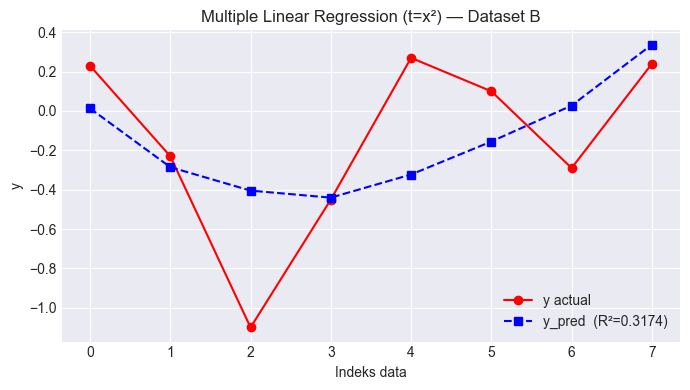

In [7]:
# ── Multiple Linear Regression — Dataset B ─────────────────────────────────
# Model: f(x, t) = a + b*x + c*t,  t = x² (variabel kedua independen)
print("Multiple Linear Regression | Dataset B")
print("Model: f(x,t) = a + b·x + c·t  (t = x²)\n")

x, y, n = xB, yB, nB
t = x**2

sum_x  = np.sum(x);  sum_t  = np.sum(t);  sum_y  = np.sum(y)
sum_x2 = np.sum(x**2); sum_xt = np.sum(x*t); sum_t2 = np.sum(t**2)
sum_xy = np.sum(x*y);  sum_ty = np.sum(t*y)

print(f"t = x² = {np.round(t,4).tolist()}")
print(f"Sums: Σx={sum_x:.4f}, Σt={sum_t:.4f}, Σy={sum_y:.4f}")
print(f"      Σx²={sum_x2:.4f}, Σxt={sum_xt:.4f}, Σxy={sum_xy:.4f}, Σt²={sum_t2:.4f}, Σty={sum_ty:.4f}")
print("\nNormal Equations (3×3):")
print(f"  [ {n:.0f},      {sum_x:.4f},  {sum_t:.4f}  ] [a]   [ {sum_y:.4f}  ]")
print(f"  [ {sum_x:.4f}, {sum_x2:.4f}, {sum_xt:.4f}  ] [b] = [ {sum_xy:.4f} ]")
print(f"  [ {sum_t:.4f},  {sum_xt:.4f}, {sum_t2:.4f}  ] [c]   [ {sum_ty:.4f} ]\n")

A_mat = [[float(n), sum_x,  sum_t],
         [sum_x,    sum_x2, sum_xt],
         [sum_t,    sum_xt, sum_t2]]
B_vec = [sum_y, sum_xy, sum_ty]
sol = gauss_jordan(A_mat, B_vec)
a, b, c = sol

y_pred = a + b*x + c*t
r2 = hitung_r2(y, y_pred)
print(f"\n── HASIL ────────────────────────────")
print(f"a = {a:.6f}")
print(f"b = {b:.6f}")
print(f"c = {c:.6f}")
print(f"Model: f(x,x²) = {a:.4f} + ({b:.4f})·x + ({c:.4f})·x²")
print(f"R²   = {r2:.6f}")
print("\nVerifikasi:")
for xi, ti, yi, yp in zip(x, t, y, y_pred):
    print(f"  x={xi}, t=x²={ti:.4f}: f_pred={yp:.4f}  | y_actual={yi}")

plt.figure(figsize=(7,4))
plt.plot(range(n), y, 'ro-', label='y actual')
plt.plot(range(n), y_pred, 'bs--', label=f'y_pred  (R²={r2:.4f})')
plt.xlabel('Indeks data')
plt.ylabel('y')
plt.title('Multiple Linear Regression (t=x²) — Dataset B')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

---
## Metode 3: Polynomial Regression (Quadratic)
### Dataset A

Polynomial Regression (Quadratic) | Dataset A
Model: y = a0 + a1*x + a2*x²

Sums: n=6, Σx=15.0, Σy=152.6
      Σx²=55.0, Σx³=225.0, Σx⁴=979.0
      Σxy=585.6, Σx²y=2488.8

Normal Equations (3×3):
  [ 6,      15.0000,  55.0000  ] [a0]   [ 152.6000   ]
  [ 15.0000, 55.0000, 225.0000  ] [a1] = [ 585.6000  ]
  [ 55.0000,225.0000, 979.0000  ] [a2]   [ 2488.8000 ]

  GAUSS-JORDAN ELIMINATION
  [Matriks Awal [A|B]]
  --------------------------------------------
  |   6.0000  15.0000  55.0000 | 152.6000 |
  |  15.0000  55.0000 225.0000 | 585.6000 |
  |  55.0000 225.0000 979.0000 | 2488.8000 |
  --------------------------------------------

  Langkah 1: normalisasi R1 (bagi 6.0000)
  R2 = R2 - (15.0000) x R1
  R3 = R3 - (55.0000) x R1
  [Setelah Langkah 1]
  --------------------------------------------
  |   1.0000   2.5000   9.1667 |  25.4333 |
  |   0.0000  17.5000  87.5000 | 204.1000 |
  |   0.0000  87.5000 474.8333 | 1089.9667 |
  --------------------------------------------

  Langkah 2: n

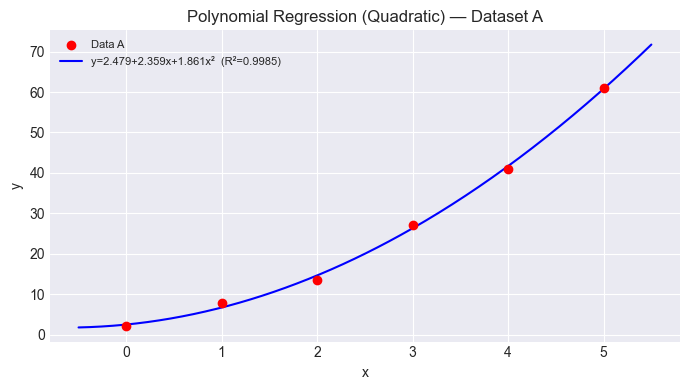

In [8]:
# ── Polynomial Regression — Dataset A ──────────────────────────────────────
# Model: y = a0 + a1*x + a2*x²
print("Polynomial Regression (Quadratic) | Dataset A")
print("Model: y = a0 + a1*x + a2*x²\n")

x, y, n = xA, yA, nA
sum_x   = np.sum(x);   sum_y   = np.sum(y)
sum_x2  = np.sum(x**2); sum_x3 = np.sum(x**3); sum_x4 = np.sum(x**4)
sum_xy  = np.sum(x*y); sum_x2y = np.sum(x**2 * y)

print(f"Sums: n={n}, Σx={sum_x}, Σy={sum_y}")
print(f"      Σx²={sum_x2}, Σx³={sum_x3}, Σx⁴={sum_x4}")
print(f"      Σxy={sum_xy}, Σx²y={sum_x2y}")
print("\nNormal Equations (3×3):")
print(f"  [ {n:.0f},      {sum_x:.4f},  {sum_x2:.4f}  ] [a0]   [ {sum_y:.4f}   ]")
print(f"  [ {sum_x:.4f}, {sum_x2:.4f}, {sum_x3:.4f}  ] [a1] = [ {sum_xy:.4f}  ]")
print(f"  [ {sum_x2:.4f},{sum_x3:.4f}, {sum_x4:.4f}  ] [a2]   [ {sum_x2y:.4f} ]\n")

A_mat = [[float(n), sum_x,  sum_x2],
         [sum_x,    sum_x2, sum_x3],
         [sum_x2,   sum_x3, sum_x4]]
B_vec = [sum_y, sum_xy, sum_x2y]
sol = gauss_jordan(A_mat, B_vec)
a0, a1, a2 = sol

y_pred = a0 + a1*x + a2*x**2
r2 = hitung_r2(y, y_pred)
print(f"\n── HASIL ────────────────────────────")
print(f"a0 = {a0:.6f}")
print(f"a1 = {a1:.6f}")
print(f"a2 = {a2:.6f}")
print(f"Model: y = {a0:.4f} + {a1:.4f}·x + {a2:.4f}·x²")
print(f"R²   = {r2:.6f}")
print("\nVerifikasi:")
for xi, yi, yp in zip(x, y, y_pred):
    print(f"  x={xi}: y_pred={yp:.4f}  | y_actual={yi}")

x_plot = np.linspace(-0.5, 5.5, 300)
y_plot = a0 + a1*x_plot + a2*x_plot**2
plt.figure(figsize=(7,4))
plt.scatter(x, y, color='red', zorder=5, label='Data A')
plt.plot(x_plot, y_plot, 'b-', label=f'y={a0:.3f}+{a1:.3f}x+{a2:.3f}x²  (R²={r2:.4f})')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Polynomial Regression (Quadratic) — Dataset A')
plt.legend(fontsize=8)
plt.grid(True)
plt.tight_layout()
plt.show()

### Dataset B

Polynomial Regression (Quadratic) | Dataset B
Model: y = a0 + a1*x + a2*x²

Sums: n=8, Σx=11.5700, Σy=-1.2300
      Σx²=21.2765, Σx³=43.4433, Σx⁴=93.6977
      Σxy=-1.0711, Σx²y=-0.4745

Normal Equations (3×3):
  [ 8,        11.5700,   21.2765  ] [a0]   [ -1.2300   ]
  [ 11.5700,  21.2765,  43.4433  ] [a1] = [ -1.0711  ]
  [ 21.2765, 43.4433, 93.6977  ] [a2]   [ -0.4745 ]

  GAUSS-JORDAN ELIMINATION
  [Matriks Awal [A|B]]
  --------------------------------------------
  |   8.0000  11.5700  21.2765 |  -1.2300 |
  |  11.5700  21.2765  43.4433 |  -1.0711 |
  |  21.2765  43.4433  93.6977 |  -0.4745 |
  --------------------------------------------

  Langkah 1: normalisasi R1 (bagi 8.0000)
  R2 = R2 - (11.5700) x R1
  R3 = R3 - (21.2765) x R1
  [Setelah Langkah 1]
  --------------------------------------------
  |   1.0000   1.4463   2.6596 |  -0.1537 |
  |   0.0000   4.5434  12.6722 |   0.7078 |
  |   0.0000  12.6722  37.1115 |   2.7967 |
  --------------------------------------------

  

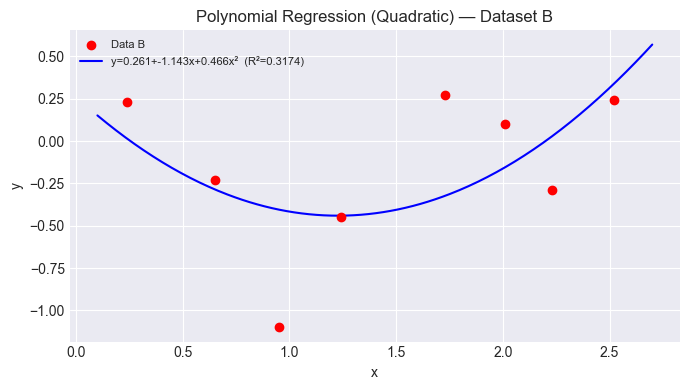

In [9]:
# ── Polynomial Regression — Dataset B ──────────────────────────────────────
print("Polynomial Regression (Quadratic) | Dataset B")
print("Model: y = a0 + a1*x + a2*x²\n")

x, y, n = xB, yB, nB
sum_x   = np.sum(x);   sum_y   = np.sum(y)
sum_x2  = np.sum(x**2); sum_x3 = np.sum(x**3); sum_x4 = np.sum(x**4)
sum_xy  = np.sum(x*y); sum_x2y = np.sum(x**2 * y)

print(f"Sums: n={n}, Σx={sum_x:.4f}, Σy={sum_y:.4f}")
print(f"      Σx²={sum_x2:.4f}, Σx³={sum_x3:.4f}, Σx⁴={sum_x4:.4f}")
print(f"      Σxy={sum_xy:.4f}, Σx²y={sum_x2y:.4f}")
print("\nNormal Equations (3×3):")
print(f"  [ {n:.0f},        {sum_x:.4f},   {sum_x2:.4f}  ] [a0]   [ {sum_y:.4f}   ]")
print(f"  [ {sum_x:.4f},  {sum_x2:.4f},  {sum_x3:.4f}  ] [a1] = [ {sum_xy:.4f}  ]")
print(f"  [ {sum_x2:.4f}, {sum_x3:.4f}, {sum_x4:.4f}  ] [a2]   [ {sum_x2y:.4f} ]\n")

A_mat = [[float(n), sum_x,  sum_x2],
         [sum_x,    sum_x2, sum_x3],
         [sum_x2,   sum_x3, sum_x4]]
B_vec = [sum_y, sum_xy, sum_x2y]
sol = gauss_jordan(A_mat, B_vec)
a0, a1, a2 = sol

y_pred = a0 + a1*x + a2*x**2
r2 = hitung_r2(y, y_pred)
print(f"\n── HASIL ────────────────────────────")
print(f"a0 = {a0:.6f}")
print(f"a1 = {a1:.6f}")
print(f"a2 = {a2:.6f}")
print(f"Model: y = {a0:.4f} + {a1:.4f}·x + {a2:.4f}·x²")
print(f"R²   = {r2:.6f}")
print("\nVerifikasi:")
for xi, yi, yp in zip(x, y, y_pred):
    print(f"  x={xi}: y_pred={yp:.4f}  | y_actual={yi}")

x_plot = np.linspace(0.1, 2.7, 300)
y_plot = a0 + a1*x_plot + a2*x_plot**2
plt.figure(figsize=(7,4))
plt.scatter(x, y, color='red', zorder=5, label='Data B')
plt.plot(x_plot, y_plot, 'b-', label=f'y={a0:.3f}+{a1:.3f}x+{a2:.3f}x²  (R²={r2:.4f})')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Polynomial Regression (Quadratic) — Dataset B')
plt.legend(fontsize=8)
plt.grid(True)
plt.tight_layout()
plt.show()

---
## Metode 4: Nonlinear Least Squares (Basis Functions)
**Model:** $f(x) = a_1 \ln(x) + a_2 \cos(x) + a_3 e^x$

> **Catatan Dataset A:** nilai `x=0` tidak terdefinisi untuk `ln(x)`, sehingga diganti dengan `x=1e-6` (pendekatan limit).

### Dataset A

Nonlinear Least Squares (Basis Functions) | Dataset A
Model: f(x) = a1·ln(x) + a2·cos(x) + a3·eˣ

x (setelah koreksi x=0 → 1e-6): [1e-06, 1.0, 2.0, 3.0, 4.0, 5.0]

Sums:
  Σφ1²=197.0678, Σφ1φ2=-15.6412, Σφ1φ3=327.9233
  Σφ2²=2.9529, Σφ2φ3=-14.0793, Σφ3²=25473.8398
  Σy·φ1=165.3326, Σy·φ2=-35.7293, Σy·φ3=11970.9569

Normal Equations (3×3):
  [ 197.0678,  -15.6412,  327.9233  ] [a1]   [ 165.3326 ]
  [ -15.6412,  2.9529,  -14.0793  ] [a2] = [ -35.7293 ]
  [ 327.9233,  -14.0793,  25473.8398  ] [a3]   [ 11970.9569 ]

  GAUSS-JORDAN ELIMINATION
  [Matriks Awal [A|B]]
  --------------------------------------------
  | 197.0678 -15.6412 327.9233 | 165.3326 |
  | -15.6412   2.9529 -14.0793 | -35.7293 |
  | 327.9233 -14.0793 25473.8398 | 11970.9569 |
  --------------------------------------------

  Langkah 1: normalisasi R1 (bagi 197.0678)
  R2 = R2 - (-15.6412) x R1
  R3 = R3 - (327.9233) x R1
  [Setelah Langkah 1]
  --------------------------------------------
  |   1.0000  -0.0794   1.6640 |

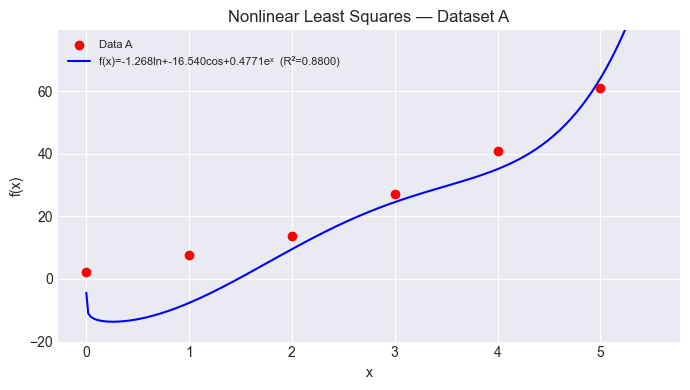

In [10]:
# ── Nonlinear Least Squares — Dataset A ────────────────────────────────────
# Model: f(x) = a1*ln(x) + a2*cos(x) + a3*e^x
# Catatan: x=0 → ln(0) = -inf, diganti 1e-6
print("Nonlinear Least Squares (Basis Functions) | Dataset A")
print("Model: f(x) = a1·ln(x) + a2·cos(x) + a3·eˣ\n")

x_raw, y, n = xA.copy(), yA, nA
x = np.where(x_raw == 0, 1e-6, x_raw)   # hindari ln(0)
print(f"x (setelah koreksi x=0 → 1e-6): {x.tolist()}")

phi1 = np.log(x); phi2 = np.cos(x); phi3 = np.exp(x)

S11 = np.sum(phi1*phi1); S12 = np.sum(phi1*phi2); S13 = np.sum(phi1*phi3)
S22 = np.sum(phi2*phi2); S23 = np.sum(phi2*phi3); S33 = np.sum(phi3*phi3)
R1  = np.sum(y*phi1);    R2  = np.sum(y*phi2);    R3  = np.sum(y*phi3)

print(f"\nSums:")
print(f"  Σφ1²={S11:.4f}, Σφ1φ2={S12:.4f}, Σφ1φ3={S13:.4f}")
print(f"  Σφ2²={S22:.4f}, Σφ2φ3={S23:.4f}, Σφ3²={S33:.4f}")
print(f"  Σy·φ1={R1:.4f}, Σy·φ2={R2:.4f}, Σy·φ3={R3:.4f}")
print("\nNormal Equations (3×3):")
print(f"  [ {S11:.4f},  {S12:.4f},  {S13:.4f}  ] [a1]   [ {R1:.4f} ]")
print(f"  [ {S12:.4f},  {S22:.4f},  {S23:.4f}  ] [a2] = [ {R2:.4f} ]")
print(f"  [ {S13:.4f},  {S23:.4f},  {S33:.4f}  ] [a3]   [ {R3:.4f} ]\n")

A_mat = [[S11, S12, S13], [S12, S22, S23], [S13, S23, S33]]
B_vec = [R1, R2, R3]
sol = gauss_jordan(A_mat, B_vec)
a1, a2, a3 = sol

y_pred = a1*phi1 + a2*phi2 + a3*phi3
r2 = hitung_r2(y, y_pred)
print(f"\n── HASIL ────────────────────────────")
print(f"a1 = {a1:.6f}")
print(f"a2 = {a2:.6f}")
print(f"a3 = {a3:.6f}")
print(f"Model: f(x) = ({a1:.4f})·ln(x) + ({a2:.4f})·cos(x) + ({a3:.4f})·eˣ")
print(f"R²   = {r2:.6f}")
print("\nVerifikasi:")
for xi, yi, yp in zip(x, y, y_pred):
    print(f"  x={xi:.4f}: f_pred={yp:.4f}  | y_actual={yi}")

x_plot = np.linspace(1e-4, 5.5, 300)
y_plot = a1*np.log(x_plot) + a2*np.cos(x_plot) + a3*np.exp(x_plot)
plt.figure(figsize=(7,4))
plt.scatter(xA, y, color='red', zorder=5, label='Data A')
plt.plot(x_plot, y_plot, 'b-', label=f'f(x)={a1:.3f}ln+{a2:.3f}cos+{a3:.4f}eˣ  (R²={r2:.4f})')
plt.ylim(-20, max(y)*1.3)
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Nonlinear Least Squares — Dataset A')
plt.legend(fontsize=8)
plt.grid(True)
plt.tight_layout()
plt.show()

### Dataset B

Nonlinear Least Squares (Basis Functions) | Dataset B
Model: f(x) = a1·ln(x) + a2·cos(x) + a3·eˣ

Sums:
  Σφ1²=4.5564, Σφ1φ2=-3.3155, Σφ1φ3=25.2192
  Σφ2²=3.2631, Σφ2φ3=-14.4815, Σφ3²=352.3881
  Σy·φ1=-0.0625, Σy·φ2=-0.8485, Σy·φ3=-1.9923

Normal Equations (3×3):
  [ 4.5564,  -3.3155,  25.2192  ] [a1]   [ -0.0625 ]
  [ -3.3155,  3.2631,  -14.4815  ] [a2] = [ -0.8485 ]
  [ 25.2192,  -14.4815,  352.3881  ] [a3]   [ -1.9923 ]

  GAUSS-JORDAN ELIMINATION
  [Matriks Awal [A|B]]
  --------------------------------------------
  |   4.5564  -3.3155  25.2192 |  -0.0625 |
  |  -3.3155   3.2631 -14.4815 |  -0.8485 |
  |  25.2192 -14.4815 352.3881 |  -1.9923 |
  --------------------------------------------

  Langkah 1: normalisasi R1 (bagi 4.5564)
  R2 = R2 - (-3.3155) x R1
  R3 = R3 - (25.2192) x R1
  [Setelah Langkah 1]
  --------------------------------------------
  |   1.0000  -0.7276   5.5349 |  -0.0137 |
  |   0.0000   0.8506   3.8692 |  -0.8940 |
  |   0.0000   3.8692 212.8031 |  -1.6464 

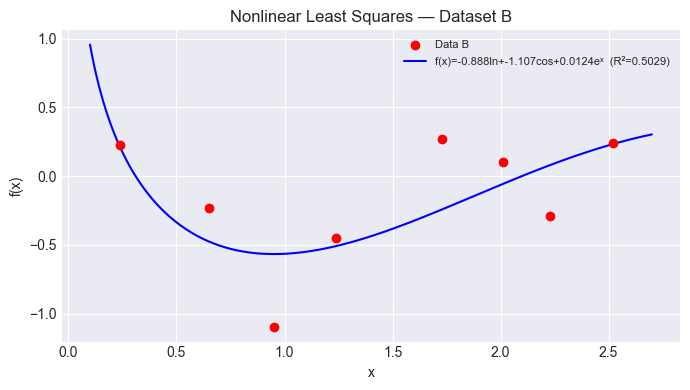

In [11]:
# ── Nonlinear Least Squares — Dataset B ────────────────────────────────────
print("Nonlinear Least Squares (Basis Functions) | Dataset B")
print("Model: f(x) = a1·ln(x) + a2·cos(x) + a3·eˣ\n")

x, y, n = xB, yB, nB
phi1 = np.log(x); phi2 = np.cos(x); phi3 = np.exp(x)

S11 = np.sum(phi1*phi1); S12 = np.sum(phi1*phi2); S13 = np.sum(phi1*phi3)
S22 = np.sum(phi2*phi2); S23 = np.sum(phi2*phi3); S33 = np.sum(phi3*phi3)
R1  = np.sum(y*phi1);    R2  = np.sum(y*phi2);    R3  = np.sum(y*phi3)

print(f"Sums:")
print(f"  Σφ1²={S11:.4f}, Σφ1φ2={S12:.4f}, Σφ1φ3={S13:.4f}")
print(f"  Σφ2²={S22:.4f}, Σφ2φ3={S23:.4f}, Σφ3²={S33:.4f}")
print(f"  Σy·φ1={R1:.4f}, Σy·φ2={R2:.4f}, Σy·φ3={R3:.4f}")
print("\nNormal Equations (3×3):")
print(f"  [ {S11:.4f},  {S12:.4f},  {S13:.4f}  ] [a1]   [ {R1:.4f} ]")
print(f"  [ {S12:.4f},  {S22:.4f},  {S23:.4f}  ] [a2] = [ {R2:.4f} ]")
print(f"  [ {S13:.4f},  {S23:.4f},  {S33:.4f}  ] [a3]   [ {R3:.4f} ]\n")

A_mat = [[S11, S12, S13], [S12, S22, S23], [S13, S23, S33]]
B_vec = [R1, R2, R3]
sol = gauss_jordan(A_mat, B_vec)
a1, a2, a3 = sol

y_pred = a1*phi1 + a2*phi2 + a3*phi3
r2 = hitung_r2(y, y_pred)
print(f"\n── HASIL ────────────────────────────")
print(f"a1 = {a1:.6f}")
print(f"a2 = {a2:.6f}")
print(f"a3 = {a3:.6f}")
print(f"Model: f(x) = ({a1:.4f})·ln(x) + ({a2:.4f})·cos(x) + ({a3:.4f})·eˣ")
print(f"R²   = {r2:.6f}")
print("\nVerifikasi:")
for xi, yi, yp in zip(x, y, y_pred):
    print(f"  x={xi}: f_pred={yp:.4f}  | y_actual={yi}")

x_plot = np.linspace(0.1, 2.7, 300)
y_plot = a1*np.log(x_plot) + a2*np.cos(x_plot) + a3*np.exp(x_plot)
plt.figure(figsize=(7,4))
plt.scatter(x, y, color='red', zorder=5, label='Data B')
plt.plot(x_plot, y_plot, 'b-', label=f'f(x)={a1:.3f}ln+{a2:.3f}cos+{a3:.4f}eˣ  (R²={r2:.4f})')
plt.xlabel('x'); plt.ylabel('f(x)')
plt.title('Nonlinear Least Squares — Dataset B')
plt.legend(fontsize=8); plt.grid(True); plt.tight_layout(); plt.show()

---
## Metode 5: Linearization Method (Exponential Fit)
**Model:** $y = b \cdot e^{ax}$, transformasi: $z = \ln(y) = \ln(b) + a x$

> **Syarat:** semua nilai `y > 0`.  
> Dataset B mengandung `y` negatif → linearisasi tidak bisa diterapkan langsung. Sebagai alternatif, digunakan **shift**: `y_shift = y - min(y) + ε` agar semua nilai positif.

### Dataset A

Linearization Method (Exponential Fit) | Dataset A
Model: y = b·eˢ⁽ᵃˣ⁾,  transformasi: z = ln(y) = ln(b) + a·x

z = ln(y) = [0.741937, 2.04122, 2.61007, 3.303217, 3.71113, 4.112512]
Sums: n=6, Σx=15.0, Σz=16.520086, Σx²=55.0, Σxz=52.578090

Normal Equations (2×2)  [z = A + B·x]:
  [ 6,      15.0000  ] [A]   [ 16.52009  ]
  [ 15.0000, 55.0000  ] [B] = [ 52.57809 ]

  GAUSS-JORDAN ELIMINATION
  [Matriks Awal [A|B]]
  --------------------------------------------
  |   6.0000  15.0000 |  16.5201 |
  |  15.0000  55.0000 |  52.5781 |
  --------------------------------------------

  Langkah 1: normalisasi R1 (bagi 6.0000)
  R2 = R2 - (15.0000) x R1
  [Setelah Langkah 1]
  --------------------------------------------
  |   1.0000   2.5000 |   2.7533 |
  |   0.0000  17.5000 |  11.2779 |
  --------------------------------------------

  Langkah 2: normalisasi R2 (bagi 17.5000)
  R1 = R1 - (2.5000) x R2
  [Setelah Langkah 2]
  --------------------------------------------
  |   1.0000   0.0000 | 

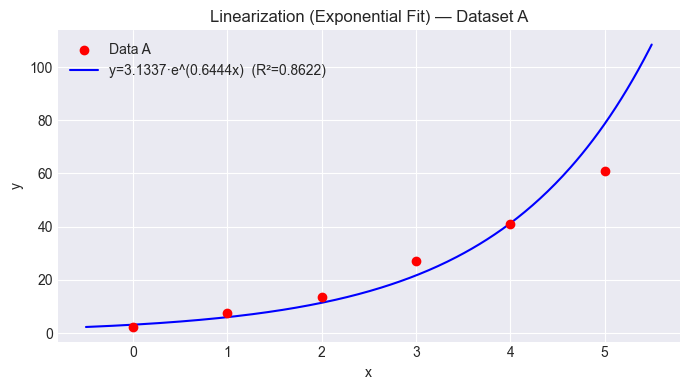

In [12]:
# ── Linearization (Exponential) — Dataset A ────────────────────────────────
# Model: y = b * e^(a*x),  transformasi z = ln(y)
print("Linearization Method (Exponential Fit) | Dataset A")
print("Model: y = b·eˢ⁽ᵃˣ⁾,  transformasi: z = ln(y) = ln(b) + a·x\n")

x, y, n = xA, yA, nA
# Semua y > 0 → aman
z = np.log(y)

sum_x  = np.sum(x); sum_z  = np.sum(z)
sum_x2 = np.sum(x**2); sum_xz = np.sum(x*z)

print(f"z = ln(y) = {np.round(z, 6).tolist()}")
print(f"Sums: n={n}, Σx={sum_x}, Σz={sum_z:.6f}, Σx²={sum_x2}, Σxz={sum_xz:.6f}")
print("\nNormal Equations (2×2)  [z = A + B·x]:")
print(f"  [ {n:.0f},      {sum_x:.4f}  ] [A]   [ {sum_z:.5f}  ]")
print(f"  [ {sum_x:.4f}, {sum_x2:.4f}  ] [B] = [ {sum_xz:.5f} ]\n")

A_mat = [[float(n), sum_x], [sum_x, sum_x2]]
B_vec = [sum_z, sum_xz]
sol = gauss_jordan(A_mat, B_vec)
A_c, B_c = sol
a = B_c; b = np.exp(A_c)

y_pred = b * np.exp(a * x)
r2 = hitung_r2(y, y_pred)
print(f"\n── HASIL ────────────────────────────")
print(f"A = ln(b) = {A_c:.6f}")
print(f"B = a     = {a:.6f}")
print(f"b = e^A   = {b:.6f}")
print(f"Model: y = {b:.4f}·e^({a:.4f}·x)")
print(f"R²   = {r2:.6f}")
print("\nVerifikasi:")
for xi, yi, yp in zip(x, y, y_pred):
    print(f"  x={xi}: y_pred={yp:.4f}  | y_actual={yi}")

x_plot = np.linspace(-0.5, 5.5, 300)
y_plot = b * np.exp(a * x_plot)
plt.figure(figsize=(7,4))
plt.scatter(x, y, color='red', zorder=5, label='Data A')
plt.plot(x_plot, y_plot, 'b-', label=f'y={b:.4f}·e^({a:.4f}x)  (R²={r2:.4f})')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Linearization (Exponential Fit) — Dataset A')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Dataset B

Linearization Method (Exponential Fit) | Dataset B
Karena y mengandung nilai negatif, digunakan shift:
  y_shift = y - min(y) + 0.01

y_shift = [1.34, 0.88, 0.01, 0.66, 1.38, 1.21, 0.82, 1.35]
z = ln(y_shift) = [0.29267, -0.127833, -4.60517, -0.415515, 0.322083, 0.19062, -0.198451, 0.300105]
Sums: n=8, Σx=11.5700, Σz=-4.241492, Σx²=21.2765, Σxz=-3.648932

Normal Equations (2×2)  [z = A + B·x]:
  [ 8,       11.5700  ] [A]   [ -4.24149  ]
  [ 11.5700, 21.2765  ] [B] = [ -3.64893 ]

  GAUSS-JORDAN ELIMINATION
  [Matriks Awal [A|B]]
  --------------------------------------------
  |   8.0000  11.5700 |  -4.2415 |
  |  11.5700  21.2765 |  -3.6489 |
  --------------------------------------------

  Langkah 1: normalisasi R1 (bagi 8.0000)
  R2 = R2 - (11.5700) x R1
  [Setelah Langkah 1]
  --------------------------------------------
  |   1.0000   1.4463 |  -0.5302 |
  |   0.0000   4.5434 |   2.4853 |
  --------------------------------------------

  Langkah 2: normalisasi R2 (bagi 4.5434)
  

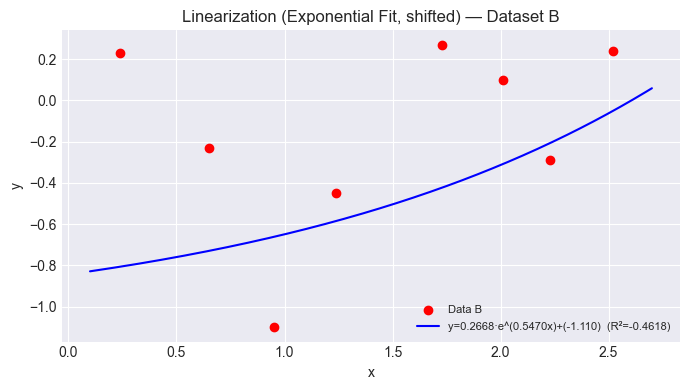

In [13]:
# ── Linearization (Exponential) — Dataset B ────────────────────────────────
# y mengandung nilai negatif → tidak bisa ln(y) langsung
# Solusi: shift → y_shift = y - min(y) + eps,  lalu fit y_shift
# Model akhir: y_shift = b * e^(a*x)  →  y = b*e^(a*x) + min(y) - eps
print("Linearization Method (Exponential Fit) | Dataset B")
print("Karena y mengandung nilai negatif, digunakan shift:")
print("  y_shift = y - min(y) + 0.01\n")

x, y, n = xB, yB, nB
eps = 0.01
y_min = np.min(y)
y_shift = y - y_min + eps
z = np.log(y_shift)

sum_x  = np.sum(x); sum_z  = np.sum(z)
sum_x2 = np.sum(x**2); sum_xz = np.sum(x*z)

print(f"y_shift = {np.round(y_shift, 4).tolist()}")
print(f"z = ln(y_shift) = {np.round(z, 6).tolist()}")
print(f"Sums: n={n}, Σx={sum_x:.4f}, Σz={sum_z:.6f}, Σx²={sum_x2:.4f}, Σxz={sum_xz:.6f}")
print("\nNormal Equations (2×2)  [z = A + B·x]:")
print(f"  [ {n:.0f},       {sum_x:.4f}  ] [A]   [ {sum_z:.5f}  ]")
print(f"  [ {sum_x:.4f}, {sum_x2:.4f}  ] [B] = [ {sum_xz:.5f} ]\n")

A_mat = [[float(n), sum_x], [sum_x, sum_x2]]
B_vec = [sum_z, sum_xz]
sol = gauss_jordan(A_mat, B_vec)
A_c, B_c = sol
a = B_c; b = np.exp(A_c)

y_shift_pred = b * np.exp(a * x)
y_pred = y_shift_pred + y_min - eps   # kembalikan ke skala asli
r2 = hitung_r2(y, y_pred)
print(f"\n── HASIL ────────────────────────────")
print(f"A = ln(b) = {A_c:.6f}")
print(f"B = a     = {a:.6f}")
print(f"b = e^A   = {b:.6f}")
print(f"Model (shifted): y_shift = {b:.4f}·e^({a:.4f}·x)")
print(f"Model (asli):    y = {b:.4f}·e^({a:.4f}·x) + ({y_min - eps:.4f})")
print(f"R²   = {r2:.6f}")
print("\nVerifikasi:")
for xi, yi, yp in zip(x, y, y_pred):
    print(f"  x={xi}: y_pred={yp:.4f}  | y_actual={yi}")

x_plot = np.linspace(0.1, 2.7, 300)
y_plot = b * np.exp(a * x_plot) + y_min - eps
plt.figure(figsize=(7,4))
plt.scatter(x, y, color='red', zorder=5, label='Data B')
plt.plot(x_plot, y_plot, 'b-', label=f'y={b:.4f}·e^({a:.4f}x)+({y_min-eps:.3f})  (R²={r2:.4f})')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Linearization (Exponential Fit, shifted) — Dataset B')
plt.legend(fontsize=8)
plt.grid(True)
plt.tight_layout()
plt.show()

## Bonus pengerjaan sesuai urutan di materi
### Contoh 1 (dari Materi)
`x = [1, 2, 3]`, `y = [5.1, 5.9, 6.3]`

Contoh 1: Linear Regression | Data dari Materi
Model: y = a0 + a1*x

Sums: n=3, Σx=6.0, Σy=17.3, Σx²=14.0, Σxy=35.8

Normal Equations:
  [ 3,    6  ] [a0]   [ 17.3  ]
  [ 6, 14  ] [a1] = [ 35.8 ]

  GAUSS-JORDAN ELIMINATION
  [Matriks Awal [A|B]]
  --------------------------------------------
  |   3.0000   6.0000 |  17.3000 |
  |   6.0000  14.0000 |  35.8000 |
  --------------------------------------------

  Langkah 1: normalisasi R1 (bagi 3.0000)
  R2 = R2 - (6.0000) x R1
  [Setelah Langkah 1]
  --------------------------------------------
  |   1.0000   2.0000 |   5.7667 |
  |   0.0000   2.0000 |   1.2000 |
  --------------------------------------------

  Langkah 2: normalisasi R2 (bagi 2.0000)
  R1 = R1 - (2.0000) x R2
  [Setelah Langkah 2]
  --------------------------------------------
  |   1.0000   0.0000 |   4.5667 |
  |   0.0000   1.0000 |   0.6000 |
  --------------------------------------------

── HASIL ────────────────────────────
a0 (intercept) = 4.566667
a1 (slope)    

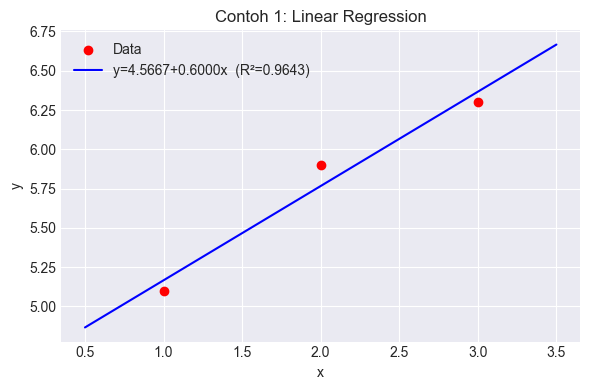

In [14]:
# ── Contoh 1: Linear Regression (dari materi) ──────────────────────────────
# Data: x=[1,2,3], y=[5.1, 5.9, 6.3]
print("Contoh 1: Linear Regression | Data dari Materi")
print("Model: y = a0 + a1*x\n")

x = np.array([1, 2, 3], dtype=float)
y = np.array([5.1, 5.9, 6.3], dtype=float)
n = len(x)

sum_x  = np.sum(x);  sum_y  = np.sum(y)
sum_x2 = np.sum(x**2); sum_xy = np.sum(x*y)

print(f"Sums: n={n}, Σx={sum_x}, Σy={sum_y}, Σx²={sum_x2}, Σxy={sum_xy}")
print("\nNormal Equations:")
print(f"  [ {n:.0f},    {sum_x:.0f}  ] [a0]   [ {sum_y:.1f}  ]")
print(f"  [ {sum_x:.0f}, {sum_x2:.0f}  ] [a1] = [ {sum_xy:.1f} ]\n")

A_mat = [[float(n), sum_x], [sum_x, sum_x2]]
B_vec = [sum_y, sum_xy]
sol = gauss_jordan(A_mat, B_vec)
a0, a1 = sol

y_pred = a0 + a1*x
r2 = hitung_r2(y, y_pred)
print(f"\n── HASIL ────────────────────────────")
print(f"a0 (intercept) = {a0:.6f}")
print(f"a1 (slope)     = {a1:.6f}")
print(f"Model: y = {a0:.4f} + {a1:.4f}·x")
print(f"R²   = {r2:.6f}")
print("\nVerifikasi:")
for xi, yi, yp in zip(x, y, y_pred):
    print(f"  x={xi:.0f}: y_pred={yp:.4f}  | y_actual={yi}")

x_plot = np.linspace(0.5, 3.5, 200)
y_plot = a0 + a1*x_plot
plt.figure(figsize=(6,4))
plt.scatter(x, y, color='red', zorder=5, label='Data')
plt.plot(x_plot, y_plot, 'b-', label=f'y={a0:.4f}+{a1:.4f}x  (R²={r2:.4f})')
plt.xlabel('x'); plt.ylabel('y')
plt.title('Contoh 1: Linear Regression')
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

### Contoh 2 (dari Materi)
`t=[0,1,2,3]`, `x=[0.1,0.4,0.2,0.2]`, `y=[3,2,1,2]`

Contoh 2: Multiple Linear Regression | Data dari Materi
Model: f(x,t) = a + b·x + c·t

Sums: n=4, Σt=6.0, Σx=0.8999999999999999, Σy=8.0
      Σx²=0.25000000000000006, Σxt=1.4000000000000001, Σxy=1.7000000000000002, Σt²=14.0, Σty=10.0

Normal Equations (3×3):
  [ 4,    0.8999999999999999,  6  ] [a]   [ 8  ]
  [ 0.8999999999999999, 0.25000000000000006,  1.4000000000000001  ] [b] = [ 1.7000000000000002 ]
  [ 6,  1.4000000000000001,  14  ] [c]   [ 10 ]

  GAUSS-JORDAN ELIMINATION
  [Matriks Awal [A|B]]
  --------------------------------------------
  |   4.0000   0.9000   6.0000 |   8.0000 |
  |   0.9000   0.2500   1.4000 |   1.7000 |
  |   6.0000   1.4000  14.0000 |  10.0000 |
  --------------------------------------------

  Langkah 1: normalisasi R1 (bagi 4.0000)
  R2 = R2 - (0.9000) x R1
  R3 = R3 - (6.0000) x R1
  [Setelah Langkah 1]
  --------------------------------------------
  |   1.0000   0.2250   1.5000 |   2.0000 |
  |   0.0000   0.0475   0.0500 |  -0.1000 |
  |   0.0000   0.0

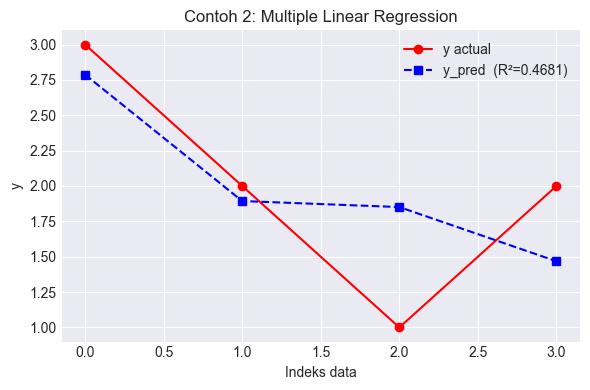

In [15]:
# ── Contoh 2: Multiple Linear Regression (dari materi) ─────────────────────
# Data: t=[0,1,2,3], x=[0.1,0.4,0.2,0.2], y=[3,2,1,2]
# Model: f(x,t) = a + b*x + c*t
print("Contoh 2: Multiple Linear Regression | Data dari Materi")
print("Model: f(x,t) = a + b·x + c·t\n")

t_d = np.array([0, 1, 2, 3], dtype=float)
x_d = np.array([0.1, 0.4, 0.2, 0.2], dtype=float)
y_d = np.array([3, 2, 1, 2], dtype=float)
n = len(t_d)

sum_t  = np.sum(t_d); sum_x  = np.sum(x_d); sum_y  = np.sum(y_d)
sum_x2 = np.sum(x_d**2); sum_xt = np.sum(x_d*t_d); sum_t2 = np.sum(t_d**2)
sum_xy = np.sum(x_d*y_d); sum_ty = np.sum(t_d*y_d)

print(f"Sums: n={n}, Σt={sum_t}, Σx={sum_x}, Σy={sum_y}")
print(f"      Σx²={sum_x2}, Σxt={sum_xt}, Σxy={sum_xy}, Σt²={sum_t2}, Σty={sum_ty}")
print("\nNormal Equations (3×3):")
print(f"  [ {n:.0f},    {sum_x},  {sum_t:.0f}  ] [a]   [ {sum_y:.0f}  ]")
print(f"  [ {sum_x}, {sum_x2},  {sum_xt}  ] [b] = [ {sum_xy} ]")
print(f"  [ {sum_t:.0f},  {sum_xt},  {sum_t2:.0f}  ] [c]   [ {sum_ty:.0f} ]\n")

A_mat = [[float(n), sum_x,  sum_t],
         [sum_x,    sum_x2, sum_xt],
         [sum_t,    sum_xt, sum_t2]]
B_vec = [sum_y, sum_xy, sum_ty]
sol = gauss_jordan(A_mat, B_vec)
a, b, c = sol

y_pred = a + b*x_d + c*t_d
r2 = hitung_r2(y_d, y_pred)
print(f"\n── HASIL ────────────────────────────")
print(f"a = {a:.6f}")
print(f"b = {b:.6f}")
print(f"c = {c:.6f}")
print(f"Model: f(x,t) = {a:.4f} + ({b:.4f})·x + ({c:.4f})·t")
print(f"R²   = {r2:.6f}")
print("\nVerifikasi:")
for xi, ti, yi, yp in zip(x_d, t_d, y_d, y_pred):
    print(f"  x={xi}, t={ti:.0f}: f_pred={yp:.4f}  | y_actual={yi}")

plt.figure(figsize=(6,4))
plt.plot(range(n), y_d, 'ro-', label='y actual')
plt.plot(range(n), y_pred, 'bs--', label=f'y_pred  (R²={r2:.4f})')
plt.xlabel('Indeks data'); plt.ylabel('y')
plt.title('Contoh 2: Multiple Linear Regression')
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

### Contoh 3 (dari Materi)
`x=[0,1,2,3,4,5]`, `y=[2.1,7.7,13.6,27.2,40.9,61.1]`

Contoh 3: Polynomial Regression (Quadratic) | Data dari Materi
Model: y = a0 + a1*x + a2*x²

Sums: n=6, Σx=15.0, Σy=152.6
      Σx²=55.0, Σx³=225.0, Σx⁴=979.0
      Σxy=585.6, Σx²y=2488.8

Normal Equations (3×3):
  [ 6,    15,  55  ] [a0]   [ 152.6   ]
  [ 15,  55, 225  ] [a1] = [ 585.6  ]
  [ 55, 225, 979  ] [a2]   [ 2488.8 ]

  GAUSS-JORDAN ELIMINATION
  [Matriks Awal [A|B]]
  --------------------------------------------
  |   6.0000  15.0000  55.0000 | 152.6000 |
  |  15.0000  55.0000 225.0000 | 585.6000 |
  |  55.0000 225.0000 979.0000 | 2488.8000 |
  --------------------------------------------

  Langkah 1: normalisasi R1 (bagi 6.0000)
  R2 = R2 - (15.0000) x R1
  R3 = R3 - (55.0000) x R1
  [Setelah Langkah 1]
  --------------------------------------------
  |   1.0000   2.5000   9.1667 |  25.4333 |
  |   0.0000  17.5000  87.5000 | 204.1000 |
  |   0.0000  87.5000 474.8333 | 1089.9667 |
  --------------------------------------------

  Langkah 2: normalisasi R2 (bagi 17.5000)
  R

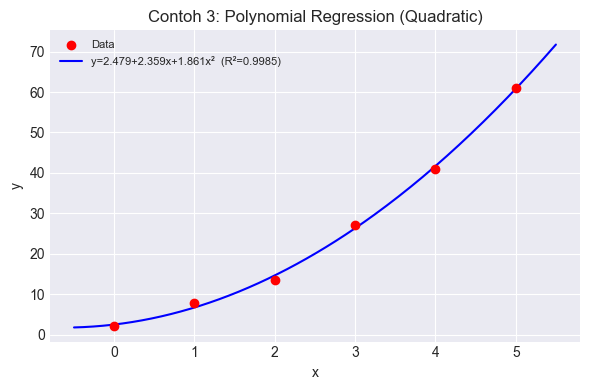

In [16]:
# ── Contoh 3: Polynomial Regression (dari materi) ──────────────────────────
# Data: x=[0,1,2,3,4,5], y=[2.1,7.7,13.6,27.2,40.9,61.1]
# Model: y = a0 + a1*x + a2*x²
print("Contoh 3: Polynomial Regression (Quadratic) | Data dari Materi")
print("Model: y = a0 + a1*x + a2*x²\n")

x = np.array([0,1,2,3,4,5], dtype=float)
y = np.array([2.1,7.7,13.6,27.2,40.9,61.1], dtype=float)
n = len(x)

sum_x   = np.sum(x);   sum_y   = np.sum(y)
sum_x2  = np.sum(x**2); sum_x3 = np.sum(x**3); sum_x4 = np.sum(x**4)
sum_xy  = np.sum(x*y); sum_x2y = np.sum(x**2*y)

print(f"Sums: n={n}, Σx={sum_x}, Σy={sum_y}")
print(f"      Σx²={sum_x2}, Σx³={sum_x3}, Σx⁴={sum_x4}")
print(f"      Σxy={sum_xy}, Σx²y={sum_x2y}")
print("\nNormal Equations (3×3):")
print(f"  [ {n:.0f},    {sum_x:.0f},  {sum_x2:.0f}  ] [a0]   [ {sum_y:.1f}   ]")
print(f"  [ {sum_x:.0f},  {sum_x2:.0f}, {sum_x3:.0f}  ] [a1] = [ {sum_xy:.1f}  ]")
print(f"  [ {sum_x2:.0f}, {sum_x3:.0f}, {sum_x4:.0f}  ] [a2]   [ {sum_x2y:.1f} ]\n")

A_mat = [[float(n), sum_x,  sum_x2],
         [sum_x,    sum_x2, sum_x3],
         [sum_x2,   sum_x3, sum_x4]]
B_vec = [sum_y, sum_xy, sum_x2y]
sol = gauss_jordan(A_mat, B_vec)
a0, a1, a2 = sol

y_pred = a0 + a1*x + a2*x**2
r2 = hitung_r2(y, y_pred)
print(f"\n── HASIL ────────────────────────────")
print(f"a0 = {a0:.6f}")
print(f"a1 = {a1:.6f}")
print(f"a2 = {a2:.6f}")
print(f"Model: y = {a0:.4f} + {a1:.4f}·x + {a2:.4f}·x²")
print(f"R²   = {r2:.6f}")
print("\nVerifikasi:")
for xi, yi, yp in zip(x, y, y_pred):
    print(f"  x={xi:.0f}: y_pred={yp:.4f}  | y_actual={yi}")

x_plot = np.linspace(-0.5, 5.5, 200)
y_plot = a0 + a1*x_plot + a2*x_plot**2
plt.figure(figsize=(6,4))
plt.scatter(x, y, color='red', zorder=5, label='Data')
plt.plot(x_plot, y_plot, 'b-', label=f'y={a0:.3f}+{a1:.3f}x+{a2:.3f}x²  (R²={r2:.4f})')
plt.xlabel('x'); plt.ylabel('y')
plt.title('Contoh 3: Polynomial Regression (Quadratic)')
plt.legend(fontsize=8); plt.grid(True); plt.tight_layout(); plt.show()

### Contoh 4 (dari Materi)
`x=[0.24,...,2.52]`, `y=[0.23,...,0.24]`  
Model: $f(x) = a_1\ln(x) + a_2\cos(x) + a_3 e^x$

Contoh 4: Nonlinear Least Squares (Basis Functions) | Data dari Materi
Model: f(x) = a1·ln(x) + a2·cos(x) + a3·eˣ

Sums:
  Σφ1²=4.5564, Σφ1φ2=-3.3155, Σφ1φ3=25.2192
  Σφ2²=3.2631, Σφ2φ3=-14.4815, Σφ3²=352.3881
  Σy·φ1=-0.0625, Σy·φ2=-0.8485, Σy·φ3=-1.9923

Normal Equations (3×3):
  [ 4.5564,  -3.3155,  25.2192  ] [a1]   [ -0.0625 ]
  [ -3.3155,  3.2631,  -14.4815  ] [a2] = [ -0.8485 ]
  [ 25.2192,  -14.4815,  352.3881  ] [a3]   [ -1.9923 ]

  GAUSS-JORDAN ELIMINATION
  [Matriks Awal [A|B]]
  --------------------------------------------
  |   4.5564  -3.3155  25.2192 |  -0.0625 |
  |  -3.3155   3.2631 -14.4815 |  -0.8485 |
  |  25.2192 -14.4815 352.3881 |  -1.9923 |
  --------------------------------------------

  Langkah 1: normalisasi R1 (bagi 4.5564)
  R2 = R2 - (-3.3155) x R1
  R3 = R3 - (25.2192) x R1
  [Setelah Langkah 1]
  --------------------------------------------
  |   1.0000  -0.7276   5.5349 |  -0.0137 |
  |   0.0000   0.8506   3.8692 |  -0.8940 |
  |   0.0000   3.8692 212

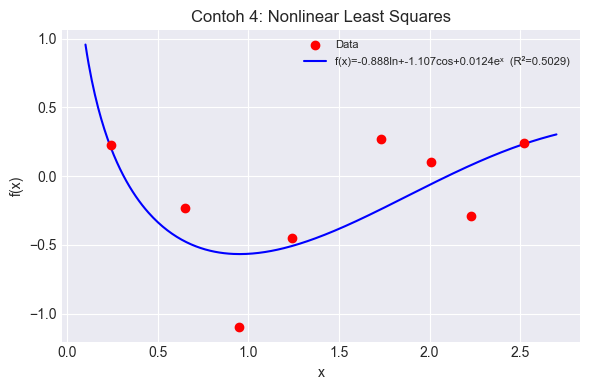

In [17]:
# ── Contoh 4: Nonlinear Least Squares (dari materi) ────────────────────────
# Model: f(x) = a1*ln(x) + a2*cos(x) + a3*e^x
print("Contoh 4: Nonlinear Least Squares (Basis Functions) | Data dari Materi")
print("Model: f(x) = a1·ln(x) + a2·cos(x) + a3·eˣ\n")

x = np.array([0.24,0.65,0.95,1.24,1.73,2.01,2.23,2.52], dtype=float)
y = np.array([0.23,-0.23,-1.1,-0.45,0.27,0.1,-0.29,0.24], dtype=float)

phi1 = np.log(x); phi2 = np.cos(x); phi3 = np.exp(x)

S11 = np.sum(phi1*phi1); S12 = np.sum(phi1*phi2); S13 = np.sum(phi1*phi3)
S22 = np.sum(phi2*phi2); S23 = np.sum(phi2*phi3); S33 = np.sum(phi3*phi3)
R1  = np.sum(y*phi1);    R2  = np.sum(y*phi2);    R3  = np.sum(y*phi3)

print(f"Sums:")
print(f"  Σφ1²={S11:.4f}, Σφ1φ2={S12:.4f}, Σφ1φ3={S13:.4f}")
print(f"  Σφ2²={S22:.4f}, Σφ2φ3={S23:.4f}, Σφ3²={S33:.4f}")
print(f"  Σy·φ1={R1:.4f}, Σy·φ2={R2:.4f}, Σy·φ3={R3:.4f}")
print("\nNormal Equations (3×3):")
print(f"  [ {S11:.4f},  {S12:.4f},  {S13:.4f}  ] [a1]   [ {R1:.4f} ]")
print(f"  [ {S12:.4f},  {S22:.4f},  {S23:.4f}  ] [a2] = [ {R2:.4f} ]")
print(f"  [ {S13:.4f},  {S23:.4f},  {S33:.4f}  ] [a3]   [ {R3:.4f} ]\n")

A_mat = [[S11,S12,S13],[S12,S22,S23],[S13,S23,S33]]
B_vec = [R1, R2, R3]
sol = gauss_jordan(A_mat, B_vec)
a1, a2, a3 = sol

y_pred = a1*phi1 + a2*phi2 + a3*phi3
r2 = hitung_r2(y, y_pred)
print(f"\n── HASIL ────────────────────────────")
print(f"a1 = {a1:.6f}")
print(f"a2 = {a2:.6f}")
print(f"a3 = {a3:.6f}")
print(f"Model: f(x) = ({a1:.4f})·ln(x) + ({a2:.4f})·cos(x) + ({a3:.4f})·eˣ")
print(f"R²   = {r2:.6f}")
print("\nVerifikasi:")
for xi, yi, yp in zip(x, y, y_pred):
    print(f"  x={xi}: f_pred={yp:.4f}  | y_actual={yi}")

x_plot = np.linspace(0.1, 2.7, 300)
y_plot = a1*np.log(x_plot) + a2*np.cos(x_plot) + a3*np.exp(x_plot)
plt.figure(figsize=(6,4))
plt.scatter(x, y, color='red', zorder=5, label='Data')
plt.plot(x_plot, y_plot, 'b-', label=f'f(x)={a1:.3f}ln+{a2:.3f}cos+{a3:.4f}eˣ  (R²={r2:.4f})')
plt.xlabel('x'); plt.ylabel('f(x)')
plt.title('Contoh 4: Nonlinear Least Squares')
plt.legend(fontsize=8); plt.grid(True); plt.tight_layout(); plt.show()

### Contoh 5 (dari Materi)
`x=[1,2,3]`, `y=[2.4, 5.0, 9.0]`  
Model: $y = b \cdot e^{ax}$

Contoh 5: Linearization Method (Exponential Fit) | Data dari Materi
Model: y = b·eˢ⁽ᵃˣ⁾,  transformasi: z = ln(y) = ln(b) + a·x

z = ln(y) = [0.875469, 1.609438, 2.197225]
Sums: n=3, Σx=6.0, Σz=4.682131, Σx²=14.0, Σxz=10.686018

Normal Equations (2×2)  [z = A + B·x]:
  [ 3,    6   ] [A]   [ 4.68213  ]
  [ 6, 14  ] [B] = [ 10.68602 ]

  GAUSS-JORDAN ELIMINATION
  [Matriks Awal [A|B]]
  --------------------------------------------
  |   3.0000   6.0000 |   4.6821 |
  |   6.0000  14.0000 |  10.6860 |
  --------------------------------------------

  Langkah 1: normalisasi R1 (bagi 3.0000)
  R2 = R2 - (6.0000) x R1
  [Setelah Langkah 1]
  --------------------------------------------
  |   1.0000   2.0000 |   1.5607 |
  |   0.0000   2.0000 |   1.3218 |
  --------------------------------------------

  Langkah 2: normalisasi R2 (bagi 2.0000)
  R1 = R1 - (2.0000) x R2
  [Setelah Langkah 2]
  --------------------------------------------
  |   1.0000   0.0000 |   0.2390 |
  |   0.0000   1.0000 

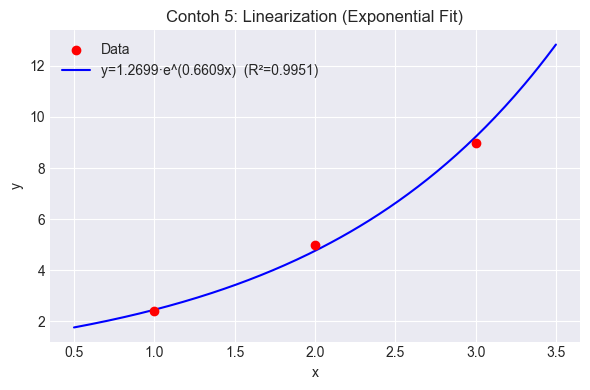

In [18]:
# ── Contoh 5: Linearization Method (dari materi) ───────────────────────────
# Model: y = b * e^(a*x),  transformasi z = ln(y)
print("Contoh 5: Linearization Method (Exponential Fit) | Data dari Materi")
print("Model: y = b·eˢ⁽ᵃˣ⁾,  transformasi: z = ln(y) = ln(b) + a·x\n")

x = np.array([1, 2, 3], dtype=float)
y = np.array([2.4, 5.0, 9.0], dtype=float)
n = len(x)

z = np.log(y)
sum_x  = np.sum(x); sum_z  = np.sum(z)
sum_x2 = np.sum(x**2); sum_xz = np.sum(x*z)

print(f"z = ln(y) = {np.round(z,6).tolist()}")
print(f"Sums: n={n}, Σx={sum_x}, Σz={sum_z:.6f}, Σx²={sum_x2}, Σxz={sum_xz:.6f}")
print("\nNormal Equations (2×2)  [z = A + B·x]:")
print(f"  [ {n:.0f},    {sum_x:.0f}   ] [A]   [ {sum_z:.5f}  ]")
print(f"  [ {sum_x:.0f}, {sum_x2:.0f}  ] [B] = [ {sum_xz:.5f} ]\n")

A_mat = [[float(n), sum_x], [sum_x, sum_x2]]
B_vec = [sum_z, sum_xz]
sol = gauss_jordan(A_mat, B_vec)
A_c, B_c = sol
a = B_c; b = np.exp(A_c)

y_pred = b * np.exp(a*x)
r2 = hitung_r2(y, y_pred)
print(f"\n── HASIL ────────────────────────────")
print(f"A = ln(b) = {A_c:.6f}")
print(f"B = a     = {a:.6f}")
print(f"b = e^A   = {b:.6f}")
print(f"Model: y = {b:.4f}·e^({a:.4f}·x)")
print(f"R²   = {r2:.6f}")
print("\nVerifikasi:")
for xi, yi, yp in zip(x, y, y_pred):
    print(f"  x={xi:.0f}: y_pred={yp:.4f}  | y_actual={yi}")

x_plot = np.linspace(0.5, 3.5, 200)
y_plot = b * np.exp(a*x_plot)
plt.figure(figsize=(6,4))
plt.scatter(x, y, color='red', zorder=5, label='Data')
plt.plot(x_plot, y_plot, 'b-', label=f'y={b:.4f}·e^({a:.4f}x)  (R²={r2:.4f})')
plt.xlabel('x'); plt.ylabel('y')
plt.title('Contoh 5: Linearization (Exponential Fit)')
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()